In [ ]:
from google.colab import drive, files
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
uploaded = files.upload()

Saving claims_phase1.parquet to claims_phase1 (2).parquet
Saving members_phase1.parquet to members_phase1 (2).parquet
Saving providers_phase1.parquet to providers_phase1 (2).parquet


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
claims = pd.read_parquet("claims_phase1.parquet")

In [ ]:
members = pd.read_parquet("members_phase1.parquet")

In [ ]:
claims.sample(3)

,member_id,age,gender,region,chronic_count,behavioral_flag,risk_level,annual_claims,claim_id,date,place_of_service,diagnosis_group,admission_flag,allowed_amount,avoidable_er,provider_id,speciality,provider_region,pcp_engaged,region_multiplier
103651,M9937,59,M,South,0,0,Low,7,C103651,2024-07-02,OP,chronic,0,278.445572,0,P536,Specialist,West,0,1.00
276743,M26484,47,F,North,0,0,Low,8,C276743,2024-06-27,ER,chronic,0,1107.965288,0,P25,Emergency,West,1,1.10
209964,M20087,69,M,West,3,0,High,24,C209964,2024-08-09,OP,low_acuity,0,618.778957,0,P615,Specialist,North,1,1.05


In [ ]:
claims.describe()

,age,chronic_count,behavioral_flag,annual_claims,date,admission_flag,allowed_amount,avoidable_er,pcp_engaged,region_multiplier
count,521314.000000,521314.000000,521314.000000,521314.000000,521314,521314.000000,5.213140e+05,521314.000000,521314.000000,521314.00000
mean,39.773891,0.871185,0.173412,13.601983,2024-07-01 01:34:43.220477696,0.167080,5.551840e+03,0.084088,0.588515,1.01947
min,0.000000,0.000000,0.000000,6.000000,2024-01-01 00:00:00,0.000000,5.932803e+01,0.000000,0.000000,0.92000
25%,26.000000,0.000000,0.000000,7.000000,2024-04-01 00:00:00,0.000000,1.843025e+02,0.000000,0.000000,0.97000
50%,41.000000,1.000000,0.000000,12.000000,2024-07-01 00:00:00,0.000000,3.008600e+02,0.000000,1.000000,1.00000
75%,55.000000,1.000000,0.000000,15.000000,2024-09-30 00:00:00,0.000000,1.518312e+03,0.000000,1.000000,1.08000
max,75.000000,6.000000,1.000000,30.000000,2024-12-30 00:00:00,1.000000,1.102023e+06,1.000000,1.000000,1.10000
std,18.977784,0.980612,0.378603,7.428066,NaN,0.373047,1.977584e+04,0.277519,0.492103,0.06296


In [ ]:
baseline_avoidable = claims ["avoidable_er"].sum()

In [ ]:
baseline_avoidable_cost = claims.loc[claims ["avoidable_er"] ==1,"allowed_amount"].sum()

In [ ]:
print ("Baseline avoidable ER count", baseline_avoidable)
print("Baseline avoidable ER cost", baseline_avoidable_cost)

Baseline avoidable ER count 43836
Baseline avoidable ER cost 107808211.25145829


In [ ]:
claims["avoidable_er"].value_counts()

,count
avoidable_er,
0,477478
1,43836


In [ ]:
claims["allowed_amount"].describe()

,allowed_amount
count,5.213140e+05
mean,5.551840e+03
std,1.977584e+04
min,5.932803e+01
25%,1.843025e+02
50%,3.008600e+02
75%,1.518312e+03
max,1.102023e+06


In [ ]:
reductions= [0.05,0.10,0.15,0.2,0.25]

In [ ]:
scenario_results =[]

In [ ]:
for r in reductions:
  remaining_visits = baseline_avoidable *(1-r)
  remaining_cost = baseline_avoidable_cost *(1-r)
  cost_savings = baseline_avoidable_cost *r
  reduced_visits = baseline_avoidable *r

  scenario_results.append({
      "Reduction_%":f"{r*100}%" ,
      "Reduced_ER_Visits": int (reduced_visits),
      "Remaining_ER_Visits": int(remaining_visits),
      "Estimated_Cost_Savings": round(cost_savings,2),
      "Remaining_Avoidable_ER_Cost_EUR":round ( remaining_cost,2)
  })




In [ ]:
scenario_df=pd.DataFrame(scenario_results)

In [ ]:
scenario_df

,Reduction_%,Reduced_ER_Visits,Remaining_ER_Visits,Estimated_Cost_Savings,Remaining_Avoidable_ER_Cost_EUR
0,5.0%,2191,41644,5390410.56,1.024178e+08
1,10.0%,4383,39452,10780821.13,9.702739e+07
2,15.0%,6575,37260,16171231.69,9.163698e+07
3,20.0%,8767,35068,21561642.25,8.624657e+07
4,25.0%,10959,32877,26952052.81,8.085616e+07


In [ ]:
baseline_total_cost =  claims["allowed_amount"].sum()

In [ ]:
scenario_df["Savings_%_of_Total_cost"] = (scenario_df["Estimated_Cost_Savings"]/baseline_total_cost).round(4)

In [ ]:
total_members=50000

In [ ]:
scenario_df["Savings_per_Member_EUR"] = (
    scenario_df["Estimated_Cost_Savings"]/total_members
).round(0)

In [ ]:
scenario_df

,Reduction_%,Reduced_ER_Visits,Remaining_ER_Visits,Estimated_Cost_Savings,Remaining_Avoidable_ER_Cost_EUR,Savings_%_of_Total_cost,Savings_per_Member_EUR
0,5.0%,2191,41644,5390410.56,1.024178e+08,0.0019,108.0
1,10.0%,4383,39452,10780821.13,9.702739e+07,0.0037,216.0
2,15.0%,6575,37260,16171231.69,9.163698e+07,0.0056,323.0
3,20.0%,8767,35068,21561642.25,8.624657e+07,0.0074,431.0
4,25.0%,10959,32877,26952052.81,8.085616e+07,0.0093,539.0


In [ ]:
claims.columns

Index(['member_id', 'age', 'gender', 'region', 'chronic_count',
       'behavioral_flag', 'risk_level', 'annual_claims', 'claim_id', 'date',
       'place_of_service', 'diagnosis_group', 'admission_flag',
       'allowed_amount', 'avoidable_er', 'provider_id', 'speciality',
       'provider_region', 'pcp_engaged', 'region_multiplier'],
      dtype='object')

In [ ]:
risk_breakdown = claims.loc [
    claims["avoidable_er"]==1
    ].groupby("risk_level", observed=True).agg(
        avoidable_er_visits=("claim_id","count"),
        avoidable_er_cost=("allowed_amount","sum")
    ).reset_index()

In [ ]:
risk_breakdown ["cost_share_%"] =(
    risk_breakdown["avoidable_er_cost"]/(risk_breakdown["avoidable_er_cost"].sum())
).round(4)

In [ ]:
risk_breakdown

,risk_level,avoidable_er_visits,avoidable_er_cost,cost_share_%
0,Low,19029,2.821133e+07,0.2617
1,Medium,14237,2.100637e+07,0.1948
2,High,10570,5.859051e+07,0.5435


In [ ]:
provider_metrics = claims.groupby("provider_id").agg(
    total_claims=("claim_id", "count"),
    total_cost=("allowed_amount", "sum"),
    er_visits=("place_of_service", lambda x: (x == "ER").sum()),
    avoidable_er_visits=("avoidable_er", "sum")
).reset_index()

provider_metrics["er_rate"] = (
    provider_metrics["er_visits"] / provider_metrics["total_claims"]
)

provider_metrics["avoidable_er_rate"] = (
    provider_metrics["avoidable_er_visits"] / provider_metrics["er_visits"]
)

provider_metrics["avoidable_er_rate"] = (
    provider_metrics["avoidable_er_rate"]
    .replace([np.inf, -np.inf], 0)
    .fillna(0)
)

provider_metrics.head()


,provider_id,total_claims,total_cost,er_visits,avoidable_er_visits,er_rate,avoidable_er_rate
0,P0,531,4.766726e+06,0,0,0.0,0.0
1,P1,489,5.422378e+06,0,0,0.0,0.0
2,P10,545,5.334216e+06,0,0,0.0,0.0
3,P100,550,4.039335e+06,0,0,0.0,0.0
4,P101,505,4.855617e+06,0,0,0.0,0.0


In [ ]:
er_providers = provider_metrics[
    provider_metrics["er_visits"]>0
].copy()

In [ ]:
er_providers.sample(5)

,provider_id,total_claims,total_cost,er_visits,avoidable_er_visits,er_rate,avoidable_er_rate
719,P746,840,1.873924e+06,743,302,0.884524,0.406460
504,P552,880,1.825351e+06,740,295,0.840909,0.398649
285,P355,822,1.725826e+06,694,283,0.844282,0.407781
178,P259,860,1.792437e+06,731,296,0.850000,0.404925
286,P356,809,1.736125e+06,689,286,0.851669,0.415094


In [ ]:
er_providers["er_visits_per_1000"]= (
    er_providers["er_visits"]/(total_members*1000)
)

In [ ]:
er_providers["avg_cost_per_er_visit"]= (
    er_providers["total_cost"]/er_providers["er_visits"]
)

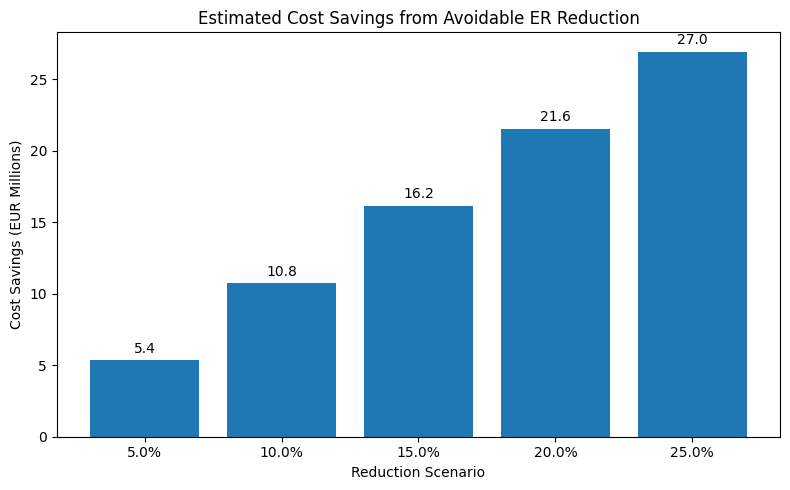

In [ ]:
import matplotlib.pyplot as plt

scenario_df["Savings_Millions"] = (
    scenario_df["Estimated_Cost_Savings"] / 1_000_000
)

plt.figure(figsize=(8,5))

plt.bar(
    scenario_df["Reduction_%"].astype(str),
    scenario_df["Savings_Millions"]
)

plt.title("Estimated Cost Savings from Avoidable ER Reduction")
plt.xlabel("Reduction Scenario")
plt.ylabel("Cost Savings (EUR Millions)")

for i, v in enumerate(scenario_df["Savings_Millions"]):
    plt.text(i, v + 0.5, f"{v:.1f}", ha='center')

plt.tight_layout()
plt.show()



In [ ]:
scenario_df.to_csv("scenario_analysis.csv", index=False)
risk_breakdown.to_csv("risk_breakdown.csv", index=False)
er_providers.to_csv("provider_er_metrics.csv", index=False)


In [ ]:
files.download("scenario_analysis.csv")
files.download("risk_breakdown.csv")
files.download("provider_er_metrics.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>